In [1]:
import numpy as np
import pandas as pd

In [3]:
data =pd.read_csv("Sentiment.csv")
data = data[["text", "sentiment"]]

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train, test = train_test_split(data, test_size = 0.1)
data_prep = train[train.sentiment != "Neutral"]

In [6]:
train_positive = data_prep[ data_prep['sentiment'] == 'Positive']
train_positive = train_positive['text']
train_negative = data_prep[ data_prep['sentiment'] == 'Negative']
train_negative = train_negative['text']

In [7]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt

In [8]:
def wc_draw(datas, color = 'black'):
    words = ' '.join(datas)
    cleaned_word = " ".join([word for word in words.split() if 'http' not in word and not word.startswith('@') and not word.startswith('#') and word != 'RT'])
    words = WordCloud(stopwords=STOPWORDS,background_color=color,width=2500,height=2000).generate(cleaned_word)
    plt.figure(1,figsize=(13, 13))
    plt.imshow(words)
    plt.axis('off')
    plt.show()

 ==== Positive words ====


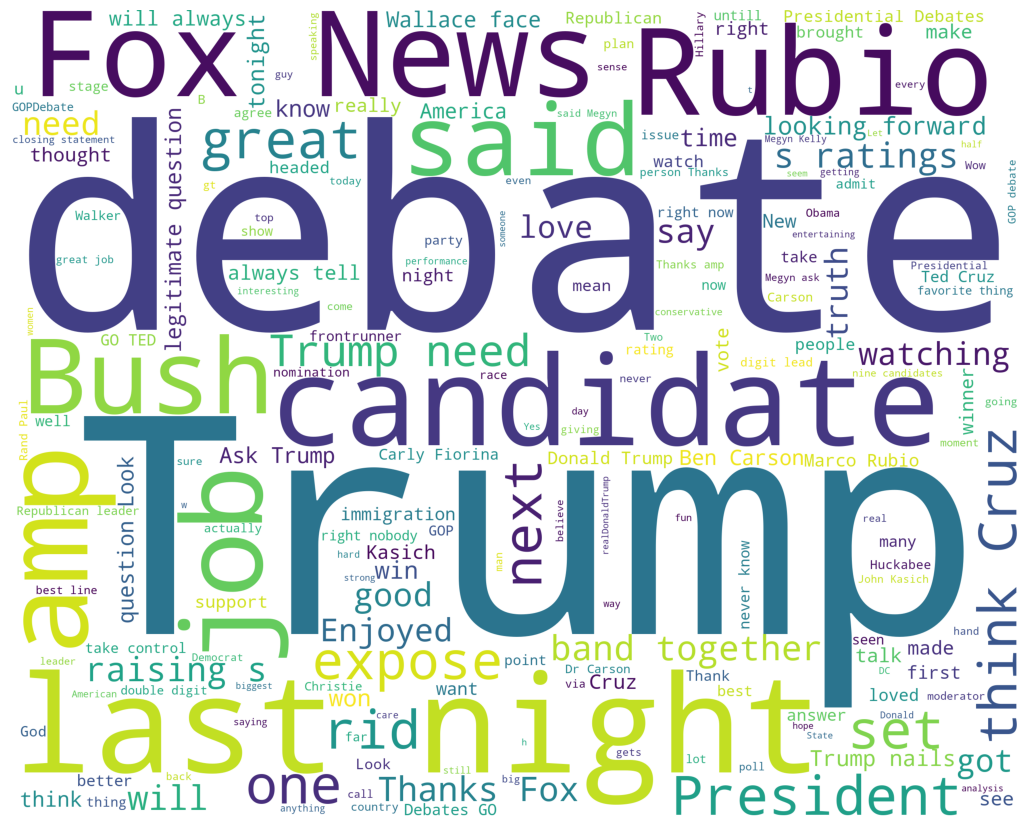

In [9]:
print(" ==== Positive words ====")
wc_draw(train_positive,'white')

====  Negative words  ====


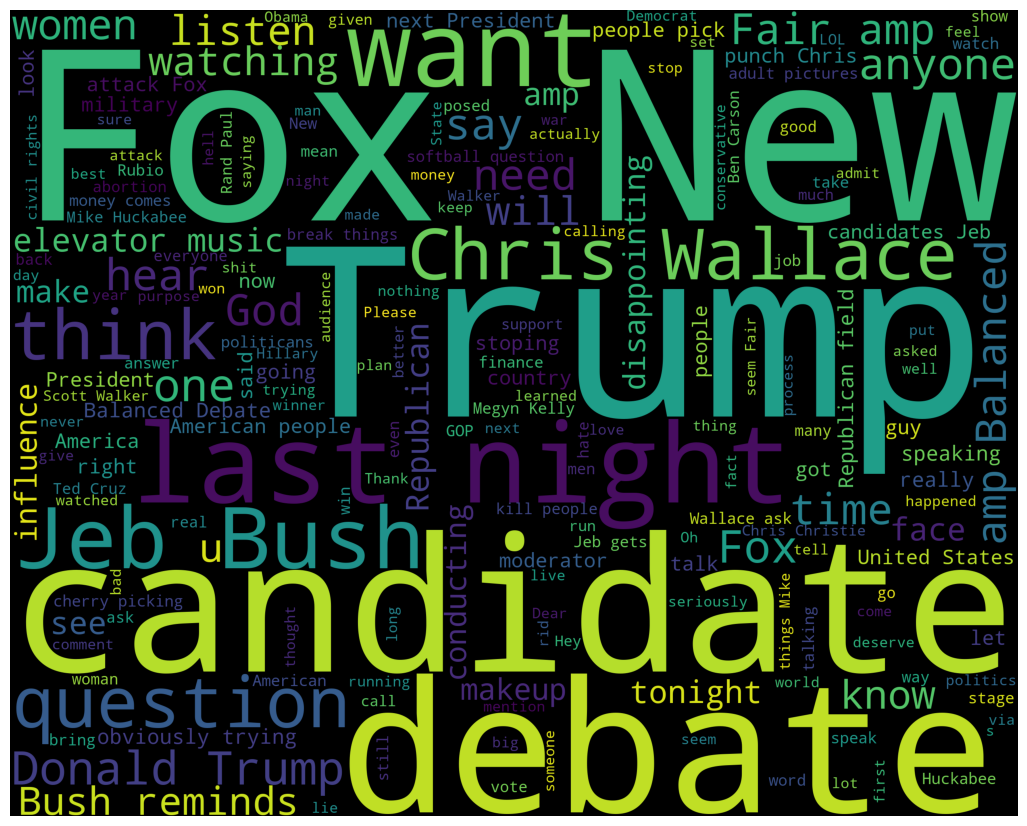

In [10]:
print("====  Negative words  ====")
wc_draw(train_negative)

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.classify import SklearnClassifier
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HARGUN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
tweets = []
stopwords = set(stopwords.words("english"))
for index, row in train.iterrows():
    filtered = [e.lower() for e in row.text.split() if len(e) >= 3]
    cleaned = [word for word in filtered if 'http' not in word and not word.startswith('@') and not word.startswith('#') and word != 'RT']
    words_without_stopwords = [word for word in cleaned if not word in stopwords]
    tweets.append((words_without_stopwords, row.sentiment))

In [13]:
test_positive = test[ test['sentiment'] == 'Positive']
test_positive = test_positive['text']
test_negative = test[ test['sentiment'] == 'Negative']
test_negative = test_negative['text']

In [14]:
def take_words_from_tweets(tweets):
    all = []
    for (words, sentiment) in tweets:
        all.extend(words)
    return all

In [15]:
def word_features(wordlist):
    wordlist = nltk.FreqDist(wordlist)
    features = wordlist.keys()
    return features


In [16]:
words_feature = word_features(take_words_from_tweets(tweets))
words_feature

dict_keys(['enjoyed', 'looking', 'forward', 'next.', 'left', 'always', 'tells', 'afraid.', 'headed', 'presidential', 'debates.', 'ted!!', 'see', 'missed', 'point,', 'know', 'comprehension', 'problem', 'types!', 'zero', 'veterans', 'among', '"how', 'fast', 'war"', 'candidates.', 'easy', 'putting', "people's", 'kids', "harm's", 'way', "can't", 'wait', 'lannister', 'kill', 'next', 'episode', 'via', 'rubio-backed', 'insurance', 'market', '"covers', 'people"', '-obamacare', 'covers', '1.6m', 'alone', 'posed', 'adult', 'pictures.should', 'bring', 'up?', 'dear', 'ted', 'cruz,', 'scriptures', 'say', 'lying', 'good', 'president?', "that's", 'thought', 'closing', 'statements', 'interesting...', 'camille', 'paglia', 'straight', 'calling', 'guest', 'column', 'good.', 'saw', 'political', 'science', 'teacher', 'news', 'talking', 'college', 'cool.', 'candidates', 'attack', 'fox', 'stoping', 'speaking.', 'huckabee.', 'fuck.', "cruz's", 'first', 'answer', 'brought', 'shit-smelling', 'face.', 'completel

In [17]:
def extract_features(document):
    document_words = set(document)
    features = {}
    for word in words_feature:
        features['contains(%s)' % word] = (word in document_words)
    return features

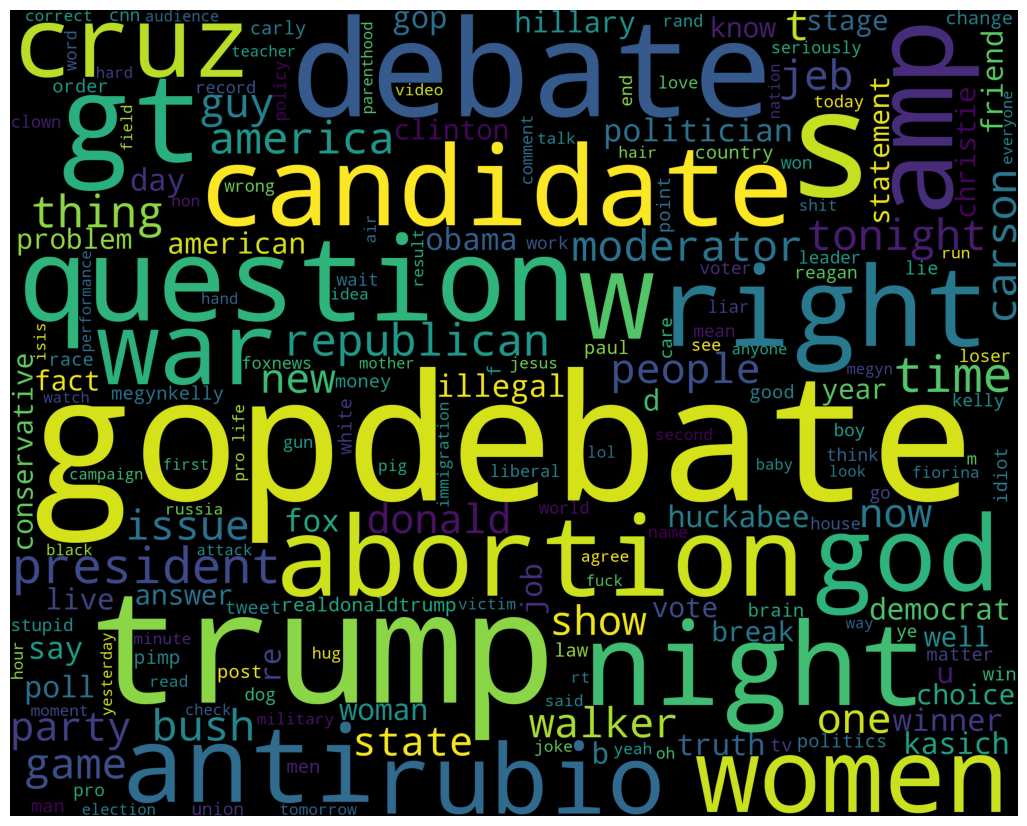

In [18]:
wc_draw(words_feature)

In [ ]:
training_set = nltk.classify.apply_features(extract_features,tweets)
classifier = nltk.NaiveBayesClassifier.train(training_set)

In [ ]:
positive_count = 0
negative_count = 0
for obj in test_positive: 
    res =  classifier.classify(extract_features(obj.split()))
    if(res == 'Positive'): 
        positive_count = positive_count + 1
for obj in test_negative: 
    res =  classifier.classify(extract_features(obj.split()))
    if(res == 'Negative'): 
        negative_count = negative_count + 1


print('[Positive]: %s/%s '  % (len(test_positive),positive_count))          
print('[Negative]: %s/%s '  % (len(test_negative),negative_count))